In [152]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# load the dataset
logs_df = pd.read_csv("../Dataset/logs.csv")

In [153]:
# understand the data
logs_df.shape

(9537, 11)

In [154]:
# check columns
logs_df.columns

Index(['session_id', 'network_packet_size', 'protocol_type', 'login_attempts',
       'session_duration', 'encryption_used', 'ip_reputation_score',
       'failed_logins', 'browser_type', 'unusual_time_access',
       'attack_detected'],
      dtype='object')

In [155]:
# check datatype
logs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB


In [156]:
# statical summary
logs_df.describe()

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000


In [157]:
# check for null values
logs_df.isnull().sum()
# remove null if exist
# logs_df.dropna(inplace=True)

session_id                0
network_packet_size       0
protocol_type             0
login_attempts            0
session_duration          0
encryption_used        1966
ip_reputation_score       0
failed_logins             0
browser_type              0
unusual_time_access       0
attack_detected           0
dtype: int64

1966 rows = too much data loss

instead od removing or deleting 

Fill null with "Unknown"

In [158]:
logs_df['encryption_used'] = logs_df[
    'encryption_used'
].fillna('Unknown')

In [159]:
logs_df.isnull().sum()

session_id             0
network_packet_size    0
protocol_type          0
login_attempts         0
session_duration       0
encryption_used        0
ip_reputation_score    0
failed_logins          0
browser_type           0
unusual_time_access    0
attack_detected        0
dtype: int64

In [160]:
# Drop Useless Column
# We do NOT need:
# session_id
logs_df.drop(
    'session_id',
    axis=1,
    inplace=True
)

In [161]:
logs_df.head()

,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


Now we need to convert text → numbers.

Columns needing encoding:

protocol_type , 
encryption_used , 
browser_type

In [162]:
# Encode Categorical Variables 
from sklearn.preprocessing import LabelEncoder
protocol_encoder = LabelEncoder()
encryption_encoder = LabelEncoder()
browser_encoder = LabelEncoder()
logs_df['protocol_type'] = protocol_encoder.fit_transform(logs_df['protocol_type'])
logs_df['encryption_used'] = encryption_encoder.fit_transform(logs_df['encryption_used'])
logs_df['browser_type'] = browser_encoder.fit_transform(logs_df['browser_type'])

In [163]:
# Print the mapping of encoded values to original labels
for i, label in enumerate(protocol_encoder.classes_):
    print(i, "=", label)


0 = ICMP
1 = TCP
2 = UDP


In [164]:
for i, label in enumerate(encryption_encoder.classes_):
    print(i, "=", label)


0 = AES
1 = DES
2 = Unknown


In [165]:
for i, label in enumerate(browser_encoder.classes_):
    print(i, "=", label)

0 = Chrome
1 = Edge
2 = Firefox
3 = Safari
4 = Unknown


In [166]:
# Data visulaization

Text(0, 0.5, 'Count')

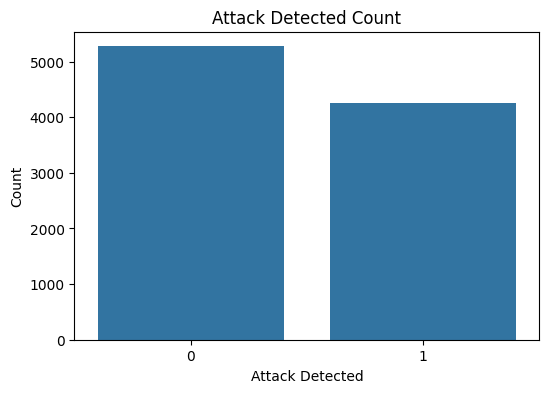

In [167]:
# 1. Attack Detected Count

# Purpose: Dataset balanced hai ya nahi check karne ke liye.

plt.figure(figsize=(6,4))

sns.countplot(x='attack_detected', data=logs_df)

plt.title("Attack Detected Count")
plt.xlabel("Attack Detected")
plt.ylabel("Count")


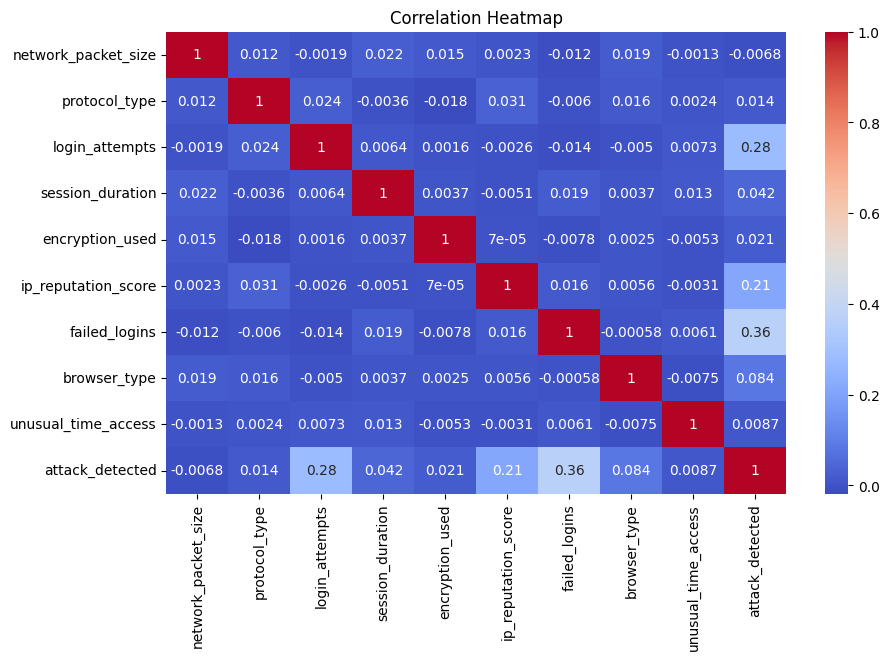

In [168]:
# Correlation Heatmap 

# Purpose: Features ka relation dekhna.

plt.figure(figsize=(10,6))

sns.heatmap(logs_df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

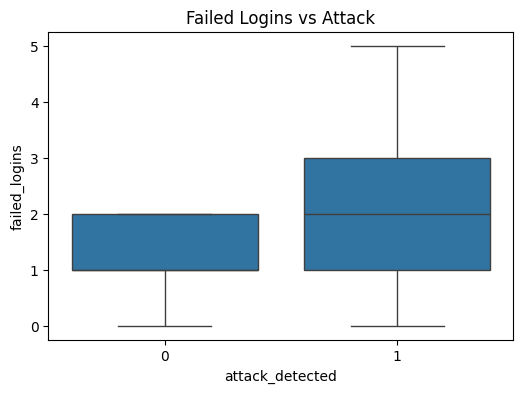

In [169]:
# Failed Logins vs Attack 
# Purpose: Attack me failed logins zyada hain ya nahi.

plt.figure(figsize=(6,4))

sns.boxplot(x='attack_detected',
            y='failed_logins',
            data=logs_df)

plt.title("Failed Logins vs Attack")

plt.show()

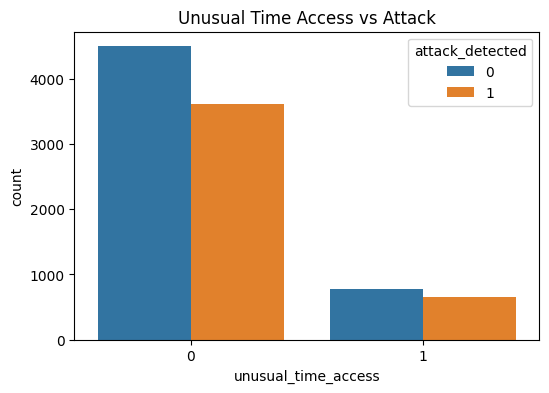

In [170]:
# Unusual Time Access vs Attack 

# Purpose: Suspicious login timing detect karna.

plt.figure(figsize=(6,4))

sns.countplot(x='unusual_time_access',
              hue='attack_detected',
              data=logs_df)

plt.title("Unusual Time Access vs Attack")

plt.show()

TRAIN THE MODEL

In [171]:
# CREATE FEATURE AND TARGET VARIABLES
# features (input)

X = logs_df.drop(
    'attack_detected',
    axis=1
)

# target (output)

y = logs_df['attack_detected']


print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (9537, 9)
y shape: (9537,)


In [172]:
# Split Dataset
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training size:", x_train.shape)
print("Testing size:", x_test.shape)

Training size: (7629, 9)
Testing size: (1908, 9)


We’ll compare:

1. Logistic Regression
2. Random Forest 

and then choose best performance model

In [182]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# convert to DataFrame AFTER scaling 
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# OPTIONAL: keep feature names safe
x_train_scaled = pd.DataFrame(x_train_scaled, columns=X.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=X.columns)

In [183]:
# Train Logistic Regression

# Import required libraries
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Step 1: Feature Scaling (VERY IMPORTANT for Logistic Regression)
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Step 2: Train Logistic Regression on scaled data
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=2000
)

logistic_model.fit(
    x_train_scaled,
    y_train
)

# Step 3: Prediction
y_pred_logistic = logistic_model.predict(
    x_test_scaled
)

In [184]:
# Check Logistic Accuracy
from sklearn.metrics import accuracy_score

logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

print(
    "Logistic Regression Accuracy:",
    logistic_accuracy
)

Logistic Regression Accuracy: 0.7452830188679245


In [185]:
# Train Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(   
    x_train_scaled,
    y_train
)

y_pred_rf = rf_model.predict(
    x_test_scaled
)

In [186]:
# Check Random Forest Accuracy
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf   
)   

print(
    "Random Forest Accuracy:",
    rf_accuracy
)

Random Forest Accuracy: 0.8967505241090147


In [187]:
# full comparison
print("Model Comparison:")
print("Logistic Regression Accuracy:", logistic_accuracy)
print("Random Forest Accuracy:", rf_accuracy)

Model Comparison:
Logistic Regression Accuracy: 0.7452830188679245
Random Forest Accuracy: 0.8967505241090147


Logistic Regression 

Fast     
Simple     
Linear model        
Usually slightly lower accuracy         

Random Forest

Captures complex patterns       
Usually higher accuracy          
Better for cybersecurity logs       

In [188]:

import joblib

# save model
joblib.dump(
    rf_model,
    "log_threat_model.pkl"
)


# save encoders
joblib.dump(
    protocol_encoder,
    "protocol_encoder.pkl"
)

joblib.dump(
    encryption_encoder,
    "encryption_encoder.pkl"
)

joblib.dump(
    browser_encoder,
    "browser_encoder.pkl"
)

['browser_encoder.pkl']

In [191]:
sample_data = pd.DataFrame([{
    'network_packet_size': 599,
    'protocol_type': 1,
    'login_attempts': 4,
    'session_duration': 492.98,
    'encryption_used': 0,
    'ip_reputation_score': 0.60,
    'failed_logins': 1,
    'browser_type': 1,
    'unusual_time_access': 0
}])

prediction = rf_model.predict(sample_data)

print("Prediction:", prediction)

Prediction: [1]


c:\Users\ASUS\Desktop\Mini-Siem\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
